In [1]:
# 1. 한글 폰트 설치 및 나눔바른고딕 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 위 작업이 끝나면 꼭 [런타임 다시 시작]을 눌러주세요!

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
### 클러스터별 최종 진단 및 지정 색상 ###
[red] Cluster 0: 성장형 오피스 밀착 상권
[blue] Cluster 1: 일반 소규모 상권
[purple] Cluster 2: 주거 밀착형 배후 상권
[green] Cluster 3: 최상위 광역 중심 상권


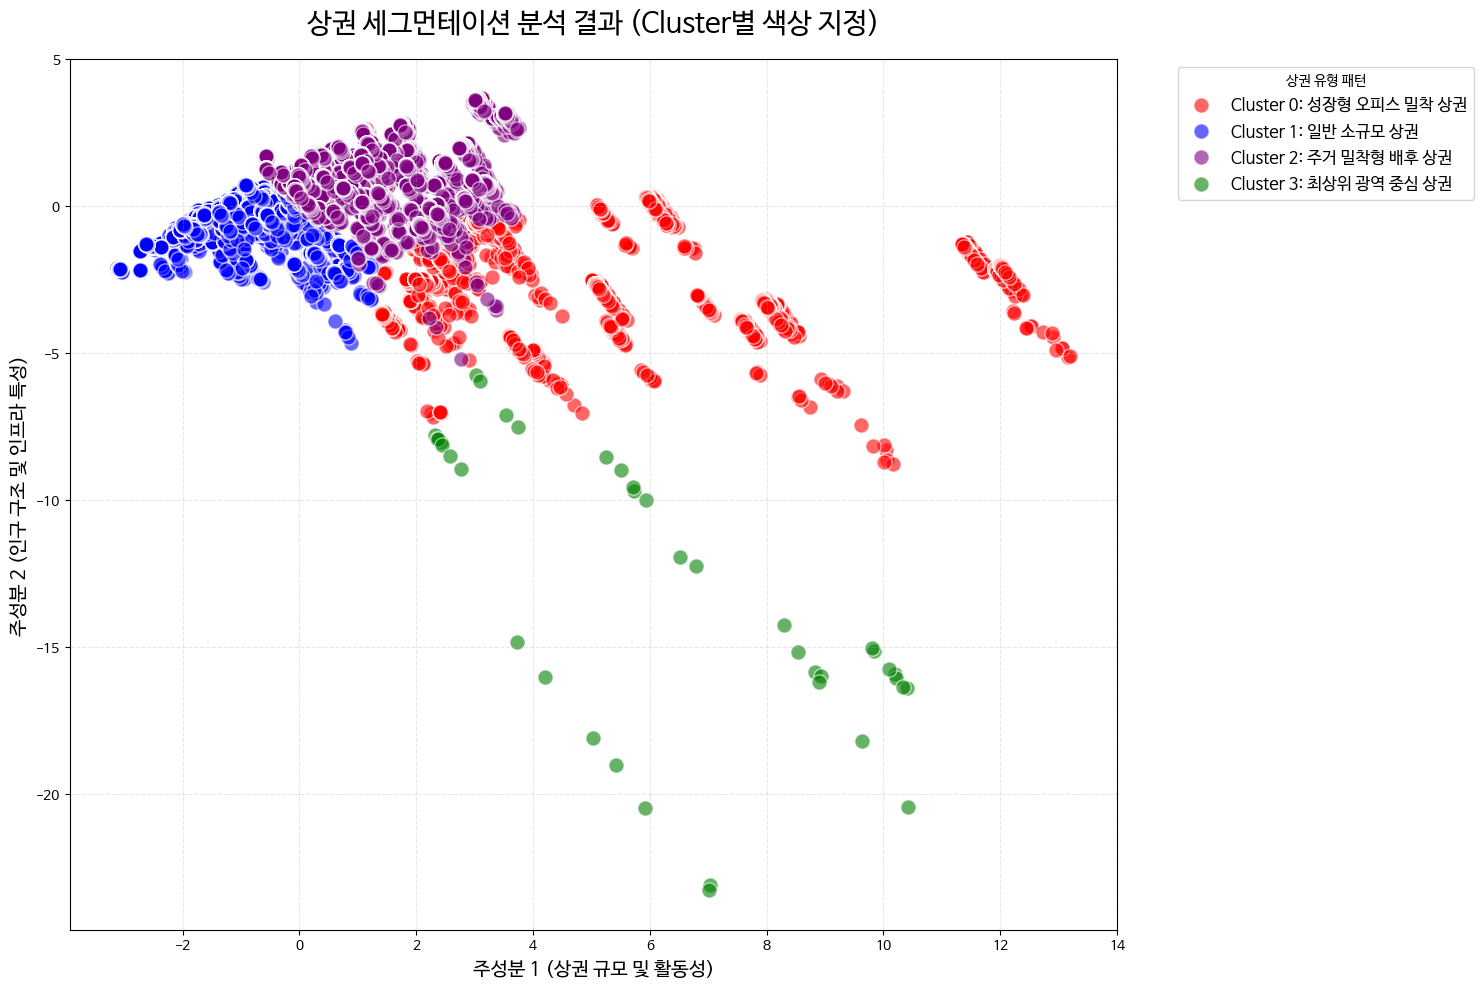

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

# --- 1. 환경 설정 및 드라이브 마운트 ---
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False
drive.mount('/content/drive')

# --- 2. 데이터 로드 ---
file_path = '/content/drive/MyDrive/itiwill_project/FINAL_상권통합_2024_2025.csv'
df = pd.read_csv(file_path)

# --- 3. 분석용 변수 선택 및 전처리 ---
features = ['총_상주인구_수', '총_직장_인구_수', '총_유동인구_수', '당월_매출_금액', '집객시설_수', '유사_업종_점포_수']
cluster_df = df[features].fillna(0)

# --- 4. 데이터 표준화 ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

# --- 5. K-Means 클러스터링 (K=4) ---
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# --- 6. 범례 세분화 로직 및 색상 매핑 ---
cluster_summary = df.groupby('Cluster')[features].mean()
overall_mean = df[features].mean()
cluster_labels = {}

# 지정된 색상 매핑 (0: 빨강, 1: 파랑, 2: 보라, 3: 초록)
color_map = {0: 'red', 1: 'blue', 2: 'purple', 3: 'green'}

# 매출액 기준 상위 군집 식별
sales_rank = cluster_summary['당월_매출_금액'].sort_values(ascending=False).index.tolist()

for i in range(k):
    top_features = cluster_summary.loc[i][cluster_summary.loc[i] > overall_mean].index.tolist()

    if '당월_매출_금액' in top_features and '총_직장_인구_수' in top_features:
        if i == sales_rank[0]:
            label = "최상위 광역 중심 상권"
        else:
            label = "성장형 오피스 밀착 상권"
    elif '총_상주인구_수' in top_features:
        label = "주거 밀착형 배후 상권"
    elif '총_유동인구_수' in top_features or '집객시설_수' in top_features:
        label = "유동인구 집객 상권"
    else:
        label = "일반 소규모 상권"

    cluster_labels[i] = f"Cluster {i}: {label}"

df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

# --- 7. 시각화 (지정 색상 적용) ---
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df['pca_x'] = pca_data[:, 0]
df['pca_y'] = pca_data[:, 1]

plt.figure(figsize=(15, 10))

# 범례와 색상을 일치시키기 위해 정렬하여 시각화
for i in range(k):
    subset = df[df['Cluster'] == i]
    plt.scatter(subset['pca_x'], subset['pca_y'],
                c=color_map[i], label=cluster_labels[i],
                s=120, alpha=0.6, edgecolor='w')

plt.title('상권 세그먼테이션 분석 결과 (Cluster별 색상 지정)', fontsize=20, pad=20)
plt.xlabel('주성분 1 (상권 규모 및 활동성)', fontsize=14)
plt.ylabel('주성분 2 (인구 구조 및 인프라 특성)', fontsize=14)
plt.legend(title='상권 유형 패턴', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

print("### 클러스터별 최종 진단 및 지정 색상 ###")
for k_val, v_val in cluster_labels.items():
    print(f"[{color_map[k_val]}] {v_val}")

plt.show()